# Choosing the Right Kernel: How SVM Decision Boundaries Change with Data Geometry

**A Practical Deep Dive into Linear, RBF, and Polynomial Kernels on the UCI Steel Plates Faults Dataset**

---

**Author:** Muhammad Usama Akram  
**Student ID:** 24178272  
**Course:** Machine Learning and Neural Network  
**GitHub Repository:** https://github.com/usamaaidev18-dot/svm-kernel-tutorial

---

## Overview

Support Vector Machines (SVMs) are powerful classifiers that separate data by finding an optimal hyperplane. But in real-world data, that hyperplane rarely works in raw feature space we need **kernels** to reshape the geometry.

This tutorial answers a deceptively simple question:

> *Given a real industrial dataset, how does kernel choice change what the SVM actually learns and when does each kernel fail?*

We use the **Steel Plates Faults dataset** (UCI, 1941 samples, 27 features, 7 fault classes) as our testbed. This is a challenging, multiclass, high-dimensional dataset from a real industrial setting far more representative than the toy datasets typically used to teach kernels.

### What You Will Learn

1. How **Linear**, **RBF**, and **Polynomial** kernels create fundamentally different decision boundaries
2. How the **C** and **gamma** hyperparameters reshape those boundaries
3. Why some kernels fail on certain data geometries
4. A practical decision framework for kernel selection in your own work

### Prerequisites

- Basic Python & scikit-learn familiarity
- Conceptual understanding of classification and cross-validation
- No prior SVM knowledge required we build from the ground up


---
## 1. Environment Setup

We begin by importing all required libraries. Every library used in this tutorial is standard in the scientific Python ecosystem.


In [ ]:
# Standard Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score)
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.pipeline import Pipeline

# Plotting Aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# Colourblind-safe palette (Okabe-Ito) for all figures
CB_PALETTE = ['#E69F00','#56B4E9','#009E73','#F0E442',
              '#0072B2','#D55E00','#CC79A7']


---
## 2. Dataset: UCI Steel Plates Faults

### 2.1 Background

The **Steel Plates Faults dataset** was collected by Semeion Research Center (Italy) and commissioned by Centro Sviluppo Materiali. It represents a real industrial quality-control problem: automatically identifying the type of surface defect on a stainless steel plate from 27 geometric and luminosity measurements.

| Property | Value |
|---|---|
| Samples | 1,941 |
| Features | 27 (geometric shape descriptors) |
| Classes | 7 fault types |
| Source | UCI ML Repository (ID: 198) |
| Licence | CC BY 4.0 |

**Why this dataset for SVM kernels?**  
With 27 features and 7 highly overlapping classes, this dataset is *not* linearly separable making it an ideal stress test for different kernel functions.

### 2.2 Loading the Data



In [ ]:
# Load Dataset
df = pd.read_csv('faults.csv')

CLASS_NAMES = ['Pastry','Z_Scratch','K_Scatch','Stains','Dirtiness','Bumps','Other_Faults']

X_raw = df.drop(columns=CLASS_NAMES)
y_raw = df[CLASS_NAMES]
# Convert one-hot → single integer label
y = y_raw.values.argmax(axis=1)        # shape: (1941,)
X = X_raw.values                       # shape: (1941, 27)

print(f"Dataset shape  : X={X.shape}, y={y.shape}")
print(f"Classes        : {CLASS_NAMES}")
print(f"Class counts   :\n{pd.Series(y).value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES)))}")

Dataset shape  : X=(1941, 27), y=(1941,)
Classes        : ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
Class counts   :
Pastry          158
Z_Scratch       190
K_Scatch        391
Stains           72
Dirtiness        55
Bumps           402
Other_Faults    673
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis

Before training any model, we need to understand the data. Three questions matter most for SVM kernel choice:

1. **How balanced are the classes?** Imbalance affects which metric to trust.
2. **Are the features scaled consistently?** SVMs are sensitive to feature scale.
3. **What does the data look like in 2D?** This hints at whether linear separation is feasible.


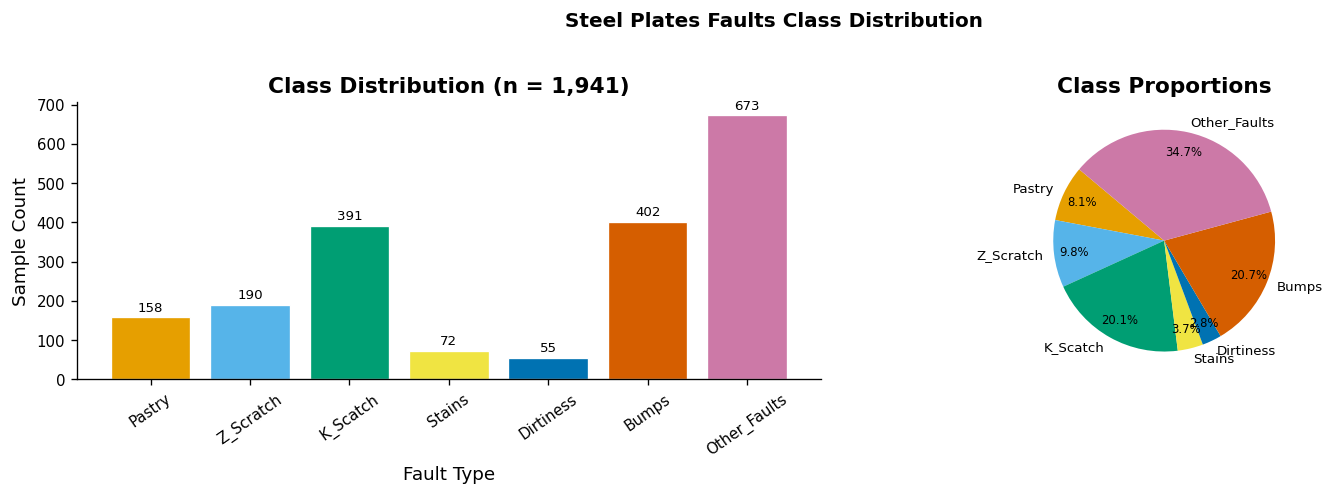

In [ ]:
# Figure 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart of class counts
counts = pd.Series(y).value_counts().sort_index()
bars = axes[0].bar(CLASS_NAMES, counts.values, color=CB_PALETTE, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution (n = 1,941)', fontweight='bold')
axes[0].set_xlabel('Fault Type')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(val), ha='center', va='bottom', fontsize=8)

# Right: pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=CLASS_NAMES, colors=CB_PALETTE,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 8}, pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(7)
axes[1].set_title('Class Proportions', fontweight='bold')

plt.suptitle('Steel Plates Faults Class Distribution',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


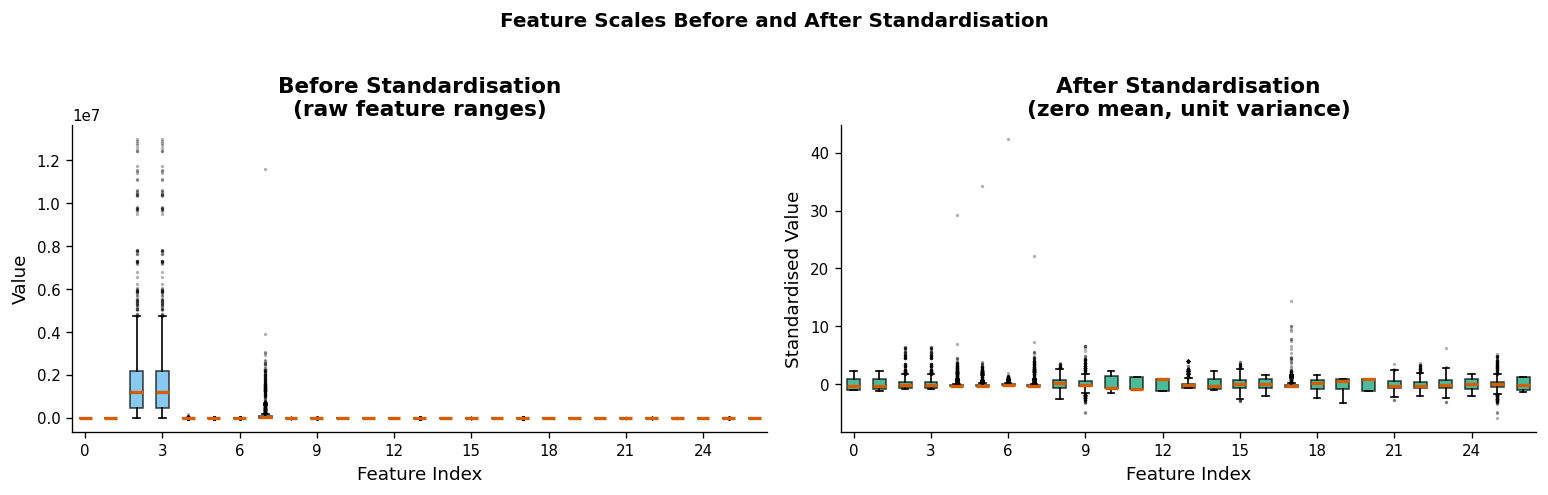

In [ ]:
# Figure 2: Feature Scale Comparison
# This motivates WHY we must standardise before applying SVM

feature_names = list(X_raw.columns)
sample_df = pd.DataFrame(X, columns=feature_names)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before scaling: boxplot of raw feature ranges
axes[0].boxplot(sample_df.values, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#56B4E9', alpha=0.7),
                medianprops=dict(color='#D55E00', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_title('Before Standardisation\n(raw feature ranges)', fontweight='bold')
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Value')
axes[0].set_xticks(range(1, 28, 3))
axes[0].set_xticklabels(range(0, 27, 3))

# After scaling
scaler_preview = StandardScaler()
X_scaled_preview = scaler_preview.fit_transform(sample_df)
axes[1].boxplot(X_scaled_preview, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#009E73', alpha=0.7),
                medianprops=dict(color='#D55E00', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].set_title('After Standardisation\n(zero mean, unit variance)', fontweight='bold')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Standardised Value')
axes[1].set_xticks(range(1, 28, 3))
axes[1].set_xticklabels(range(0, 27, 3))

plt.suptitle('Feature Scales Before and After Standardisation',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_feature_scaling.png', bbox_inches='tight', dpi=150)
plt.show()


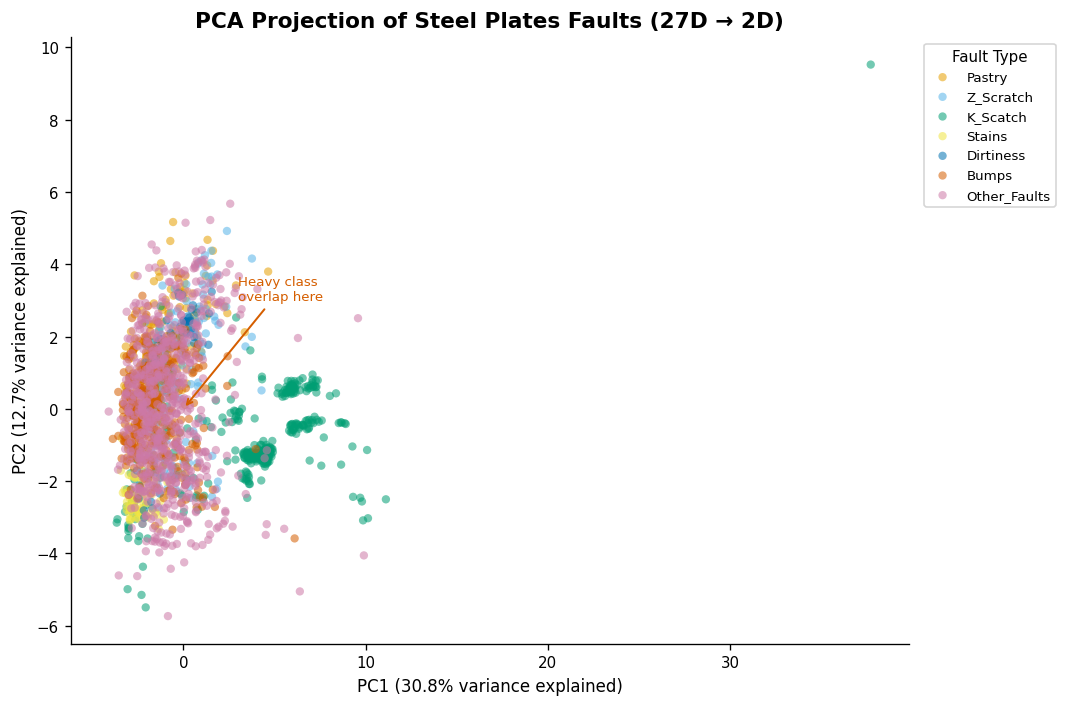

In [ ]:
# Figure 3: PCA 2D Projection, Is the Data Linearly Separable?
# We reduce 27D → 2D using PCA to visually inspect class separability.
# This is purely for visualisation; the SVM will train on the full 27 features.

scaler_pca = StandardScaler()
X_std = scaler_pca.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
for i, cls in enumerate(CLASS_NAMES):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=CB_PALETTE[i], label=cls, alpha=0.55,
               s=25, edgecolors='none')

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)', fontsize=10)
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)', fontsize=10)
ax.set_title('PCA Projection of Steel Plates Faults (27D → 2D)',
             fontweight='bold')
ax.legend(title='Fault Type', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, title_fontsize=9)

# Annotate key overlapping regions
ax.annotate('Heavy class\noverlap here', xy=(0, 0), xytext=(3, 3),
            fontsize=8, color='#D55E00',
            arrowprops=dict(arrowstyle='->', color='#D55E00', lw=1.2))

plt.tight_layout()
plt.savefig('fig3_pca_projection.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 4. SVM Theory: From Hyperplanes to Kernels

### 4.1 The Core Idea

An SVM finds the hyperplane that **maximises the margin** between classes. For two classes:

$$\underset{\mathbf{w}, b}{\text{minimise}} \quad \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1$$

The data points closest to the boundary are **support vectors** — they alone define the hyperplane.

### 4.2 The Kernel Trick

When data is not linearly separable in input space, we can implicitly map it to a higher-dimensional space using a **kernel function** $K(\mathbf{x}_i, \mathbf{x}_j)$:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^\top \phi(\mathbf{x}_j)$$

We never compute $\phi$ explicitly we only need the inner products. This is the **kernel trick**.

### 4.3 The Three Kernels We Compare

| Kernel | Formula | Key Parameters | Data Geometry |
|---|---|---|---|
| **Linear** | $K = \mathbf{x}_i^\top \mathbf{x}_j$ | C | Linearly separable data |
| **RBF (Gaussian)** | $K = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$ | C, γ | Radially clustered data |
| **Polynomial** | $K = (\gamma \mathbf{x}_i^\top \mathbf{x}_j + r)^d$ | C, γ, degree | Interaction-structured data |

### 4.4 The Hyperparameters That Matter

- **C (Regularisation):** Controls the trade-off between a wide margin and misclassification. *High C* → narrow margin, fewer training errors (risk of overfitting). *Low C* → wide margin, more tolerance for misclassification.
- **γ (Gamma, RBF/Poly):** Controls the reach of a single training example. *High γ* → tight local influence (risk of overfitting). *Low γ* → broad influence (risk of underfitting).


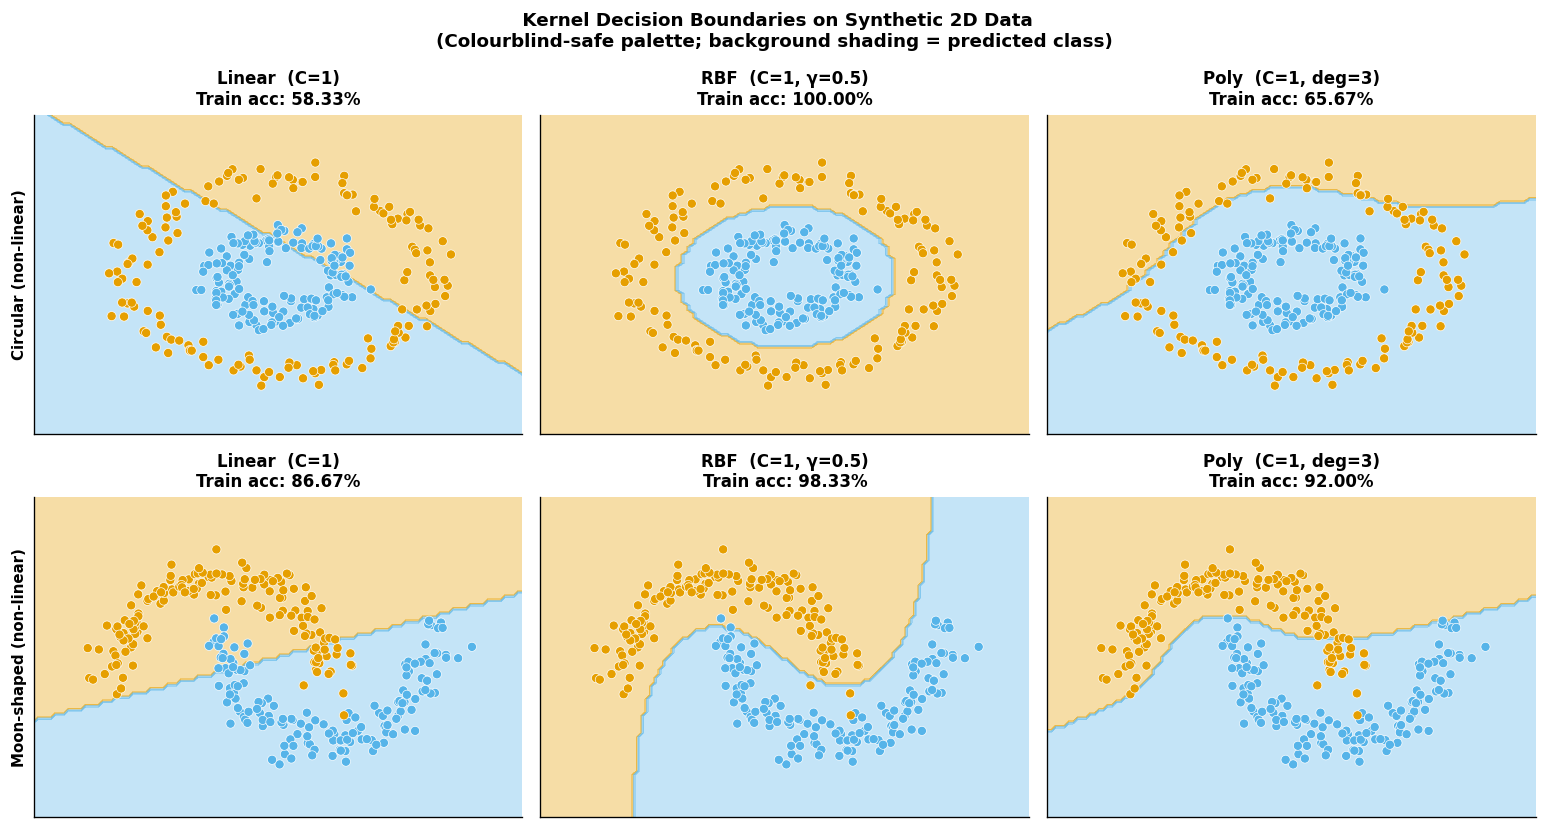

Key takeaway:


In [ ]:
# Figure 4: Visual Intuition, What Each Kernel Does
# Demonstrate kernel behaviour on synthetic 2D data (XOR-like and circular)
# to build intuition BEFORE applying to Steel Plates.

from sklearn.datasets import make_circles, make_moons
from matplotlib.colors import ListedColormap

def plot_decision_boundary(ax, clf, X_2d, y_2d, title, palette):
    """Plot filled decision regions and class scatter for a fitted SVC."""
    h = 0.04
    x_min, x_max = X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5
    y_min, y_max = X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cmap_bg  = ListedColormap([c+'55' for c in palette[:len(np.unique(y_2d))]])
    cmap_pts = ListedColormap(palette[:len(np.unique(y_2d))])
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.scatter(X_2d[:,0], X_2d[:,1], c=y_2d, cmap=cmap_pts,
               edgecolors='white', linewidths=0.4, s=30, zorder=3)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

# Synthetic datasets
np.random.seed(0)
X_circ, y_circ = make_circles(n_samples=300, noise=0.08, factor=0.4, random_state=0)
X_moon, y_moon = make_moons(n_samples=300, noise=0.12, random_state=0)

kernels = [
    ('linear', dict(C=1.0),           'Linear  (C=1)'),
    ('rbf',    dict(C=1.0, gamma=0.5),'RBF  (C=1, γ=0.5)'),
    ('poly',   dict(C=1.0, degree=3, gamma='scale'), 'Poly  (C=1, deg=3)'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
datasets = [('Circular (non-linear)', X_circ, y_circ),
            ('Moon-shaped (non-linear)', X_moon, y_moon)]

for row, (ds_name, X_ds, y_ds) in enumerate(datasets):
    for col, (kern, params, label) in enumerate(kernels):
        clf = SVC(kernel=kern, **params)
        clf.fit(X_ds, y_ds)
        acc = accuracy_score(y_ds, clf.predict(X_ds))
        title = f'{label}\nTrain acc: {acc:.2%}'
        plot_decision_boundary(axes[row, col], clf, X_ds, y_ds,
                               title, CB_PALETTE)
        if col == 0:
            axes[row, col].set_ylabel(ds_name, fontsize=9, fontweight='bold')

plt.suptitle(' Kernel Decision Boundaries on Synthetic 2D Data\n'
             '(Colourblind-safe palette; background shading = predicted class)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_synthetic_kernels.png', bbox_inches='tight', dpi=150)
plt.show()



---
## 5. Preprocessing the Steel Plates Data

### 5.1 Strategy

1. **Standardise** all 27 features (zero mean, unit variance) mandatory for SVM
2. **Stratified train/test split** (80/20) preserves class proportions despite imbalance
3. **PCA to 2D** *only for decision boundary visualisation*, not for model training

We wrap preprocessing in a `Pipeline` so that the scaler is always fitted on training data only, preventing **data leakage**.


In [ ]:
# 5.1 Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test  set: {X_test.shape[0]} samples")
print(f"Stratification check — test class counts:")
print(pd.Series(y_test).value_counts().sort_index()
        .rename(index=dict(enumerate(CLASS_NAMES))))

# 5.2 Standardise (fit ONLY on train, transform both)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)   # fit here
X_test_std  = scaler.transform(X_test)         # apply same transform

print(f"\nPost-scaling: mean ≈ {X_train_std.mean():.4f}, std ≈ {X_train_std.std():.4f}")

# 5.3 PCA 2D, for boundary visualisation only
pca_vis = PCA(n_components=2, random_state=42)
X_train_2d = pca_vis.fit_transform(X_train_std)
X_test_2d  = pca_vis.transform(X_test_std)
print(f"\n2D PCA for visualisation:")
print(f"  PC1 + PC2 explain {pca_vis.explained_variance_ratio_.sum()*100:.1f}% of variance")
print("  (Models are trained on all 27 features 2D is for figures only)")


Train set: 1552 samples
Test  set: 389 samples
Stratification check — test class counts:
Pastry           32
Z_Scratch        38
K_Scatch         78
Stains           14
Dirtiness        11
Bumps            81
Other_Faults    135
Name: count, dtype: int64

Post-scaling: mean ≈ 0.0000, std ≈ 1.0000

2D PCA for visualisation:
  PC1 + PC2 explain 43.1% of variance
  (Models are trained on all 27 features 2D is for figures only)


---
## 6. Kernel Comparison: Decision Boundaries & Performance

### 6.1 Default Hyperparameters Baseline

We first train all three kernels with their default hyperparameters. This gives us a baseline before any tuning, and lets us observe how the kernels behave out of the box.

> **Important:** Decision boundaries are plotted on the **2D PCA projection** of the test data. The SVM itself was trained on all 27 standardised features the 2D plot is a visualisation tool, not the full picture.


In [ ]:
# Train all three kernels with default parameters
kernel_configs = {
    'Linear':     SVC(kernel='linear',  C=1.0, random_state=42),
    'RBF':        SVC(kernel='rbf',     C=1.0, gamma='scale', random_state=42),
    'Polynomial': SVC(kernel='poly',    C=1.0, degree=3, gamma='scale', random_state=42),
}

results_baseline = {}
for name, clf in kernel_configs.items():
    clf.fit(X_train_std, y_train)
    y_pred = clf.predict(X_test_std)
    acc   = accuracy_score(y_test, y_pred)
    # Cross-val on training set for a more robust estimate
    cv_scores = cross_val_score(clf, X_train_std, y_train,
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='accuracy', n_jobs=-1)
    results_baseline[name] = {
        'clf': clf, 'y_pred': y_pred,
        'test_acc': acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'n_support': clf.n_support_.sum()
    }
    print(f"{name:12s} | Test Acc: {acc:.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Support Vectors: {clf.n_support_.sum()}")


Linear       | Test Acc: 0.7095 | CV: 0.7339 ± 0.0161 | Support Vectors: 931
RBF          | Test Acc: 0.7635 | CV: 0.7403 ± 0.0187 | Support Vectors: 1017
Polynomial   | Test Acc: 0.7044 | CV: 0.7068 ± 0.0197 | Support Vectors: 1080


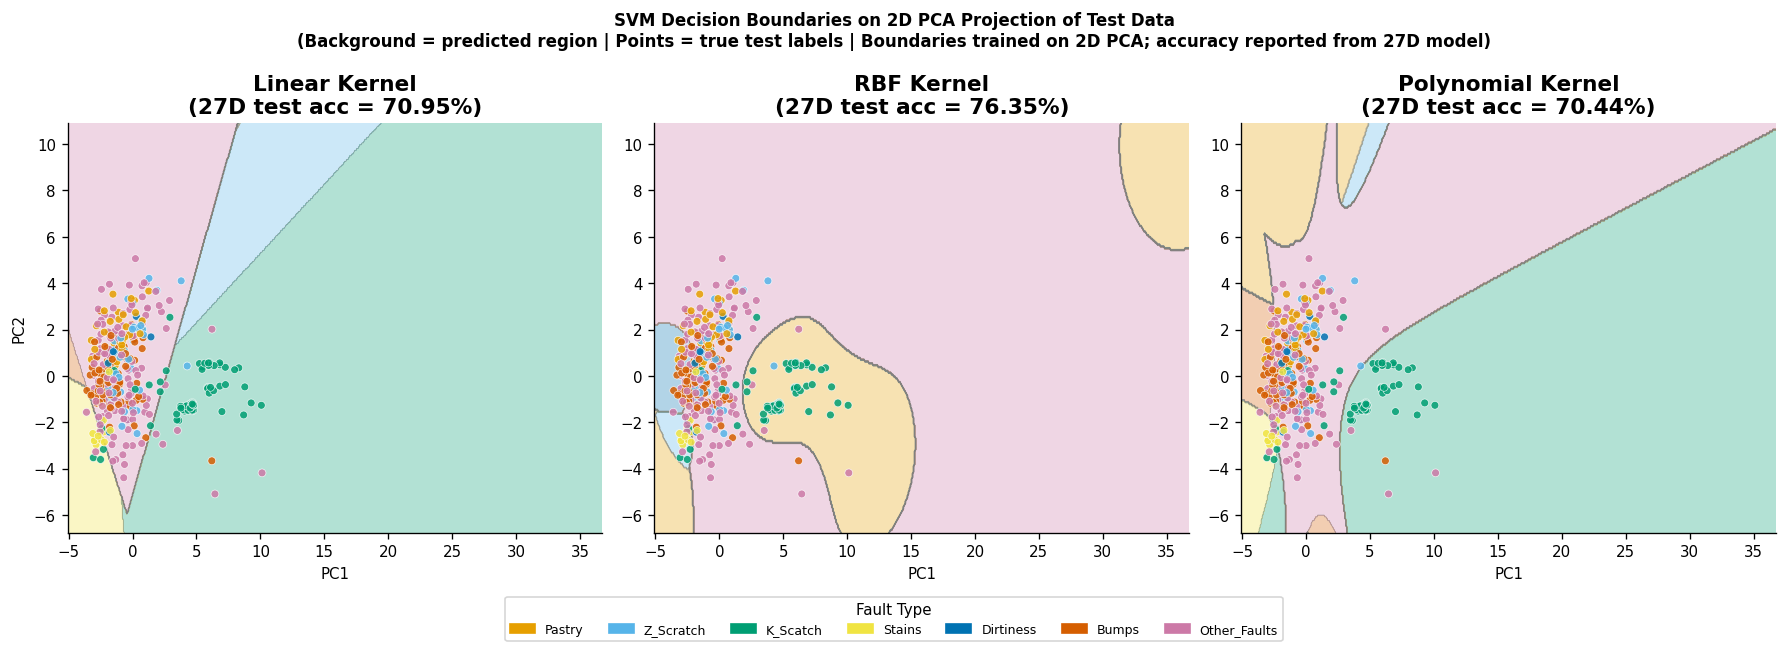

In [ ]:
# Figure 5: Decision Boundaries on 2D PCA Projection
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Build a grid over 2D PCA space
h = 0.08
x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# Train 2D versions JUST for boundary visualisation
kernel_configs_2d = {
    'Linear':     SVC(kernel='linear',  C=1.0, random_state=42),
    'RBF':        SVC(kernel='rbf',     C=1.0, gamma='scale', random_state=42),
    'Polynomial': SVC(kernel='poly',    C=1.0, degree=3, gamma='scale', random_state=42),
}

cmap_bg  = ListedColormap([c+'40' for c in CB_PALETTE])
cmap_pts = ListedColormap(CB_PALETTE)

for ax, (name, clf2d) in zip(axes, kernel_configs_2d.items()):
    clf2d.fit(X_train_2d, y_train)
    Z = clf2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.30, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='grey', linewidths=0.6, alpha=0.5)

    # Plot test points
    sc = ax.scatter(X_test_2d[:,0], X_test_2d[:,1],
                    c=y_test, cmap=cmap_pts,
                    edgecolors='white', linewidths=0.4, s=22, zorder=4, alpha=0.85)

    full_acc = results_baseline[name]['test_acc']
    ax.set_title(f'{name} Kernel\n(27D test acc = {full_acc:.2%})', fontweight='bold')
    ax.set_xlabel('PC1', fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel('PC2', fontsize=9)

# Shared legend
patches = [mpatches.Patch(color=CB_PALETTE[i], label=CLASS_NAMES[i]) for i in range(7)]
fig.legend(handles=patches, title='Fault Type', loc='lower center',
           ncol=7, fontsize=7.5, title_fontsize=9,
           bbox_to_anchor=(0.5, -0.08))

plt.suptitle('SVM Decision Boundaries on 2D PCA Projection of Test Data\n'
             '(Background = predicted region | Points = true test labels | '
             'Boundaries trained on 2D PCA; accuracy reported from 27D model)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_decision_boundaries.png', bbox_inches='tight', dpi=150)
plt.show()


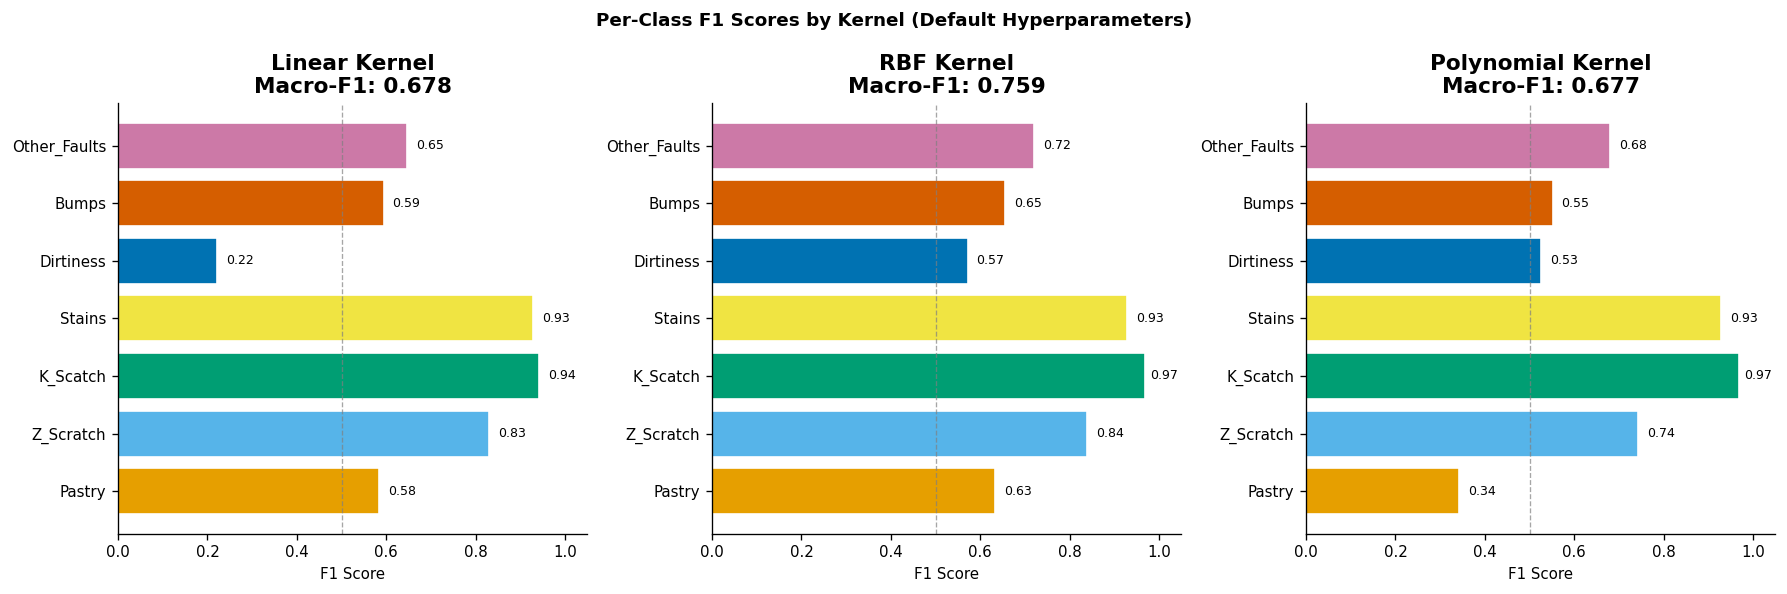

In [ ]:
# Figure 6: Per-Class Performance , Classification Reports
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, res) in zip(axes, results_baseline.items()):
    report = classification_report(y_test, res['y_pred'],
                                   target_names=CLASS_NAMES, output_dict=True)
    # Extract per-class F1 scores
    f1_scores = [report[cls]['f1-score'] for cls in CLASS_NAMES]
    colors = [CB_PALETTE[i] for i in range(7)]
    bars = ax.barh(CLASS_NAMES, f1_scores, color=colors, edgecolor='white')
    ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('F1 Score', fontsize=9)
    ax.set_title(f'{name} Kernel\nMacro-F1: {report["macro avg"]["f1-score"]:.3f}',
                 fontweight='bold')
    for bar, val in zip(bars, f1_scores):
        ax.text(min(val + 0.02, 0.98), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=7.5)

plt.suptitle('Per-Class F1 Scores by Kernel (Default Hyperparameters)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_f1_by_class.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 7. Hyperparameter Sensitivity: C and Gamma

### Why This Matters

Choosing a kernel is only half the battle. The **C** and **γ** parameters dramatically reshape the decision boundary:

- **C too low:** The margin is very wide but many training points are misclassified (underfitting)
- **C too high:** The boundary contorts around training points (overfitting)
- **γ too low (RBF):** Each point has very broad influence → smooth boundary (underfitting)
- **γ too high (RBF):** Each point has very tight influence → jagged boundary (overfitting)

We visualise this using **heatmaps of cross-validated accuracy** across a grid of C and γ values.


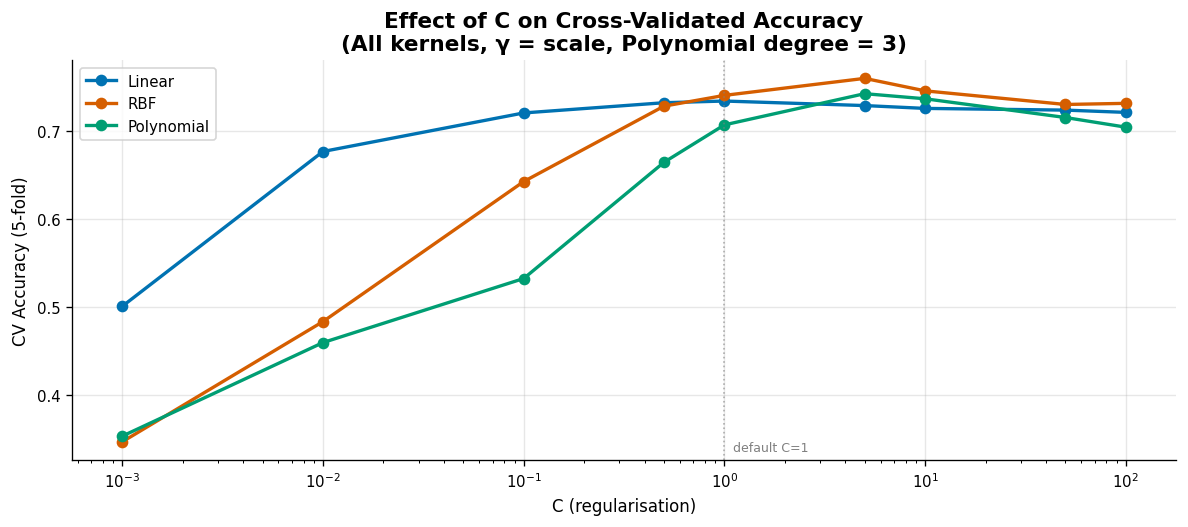

In [ ]:
# Figure 7: C Sensitivity All Three Kernels
# How does test accuracy change as we sweep C?

C_values = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]
cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

c_results = {k: [] for k in ['Linear','RBF','Polynomial']}

for C in C_values:
    for name, kern, extra in [
        ('Linear',     'linear', {}),
        ('RBF',        'rbf',    {'gamma': 'scale'}),
        ('Polynomial', 'poly',   {'degree': 3, 'gamma': 'scale'}),
    ]:
        clf_c = SVC(kernel=kern, C=C, random_state=42, **extra)
        scores = cross_val_score(clf_c, X_train_std, y_train,
                                 cv=cv_split, scoring='accuracy', n_jobs=-1)
        c_results[name].append(scores.mean())

fig, ax = plt.subplots(figsize=(10, 4.5))
for name, color in zip(['Linear','RBF','Polynomial'], ['#0072B2','#D55E00','#009E73']):
    ax.semilogx(C_values, c_results[name], 'o-', color=color,
                label=name, linewidth=2, markersize=6)

ax.set_xlabel('C (regularisation)', fontsize=10)
ax.set_ylabel('CV Accuracy (5-fold)', fontsize=10)
ax.set_title('Effect of C on Cross-Validated Accuracy\n'
             '(All kernels, γ = scale, Polynomial degree = 3)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.axvline(x=1, color='grey', linestyle=':', linewidth=1, alpha=0.6)
ax.text(1.1, ax.get_ylim()[0]+0.01, 'default C=1', fontsize=7.5, color='grey')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_c_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()


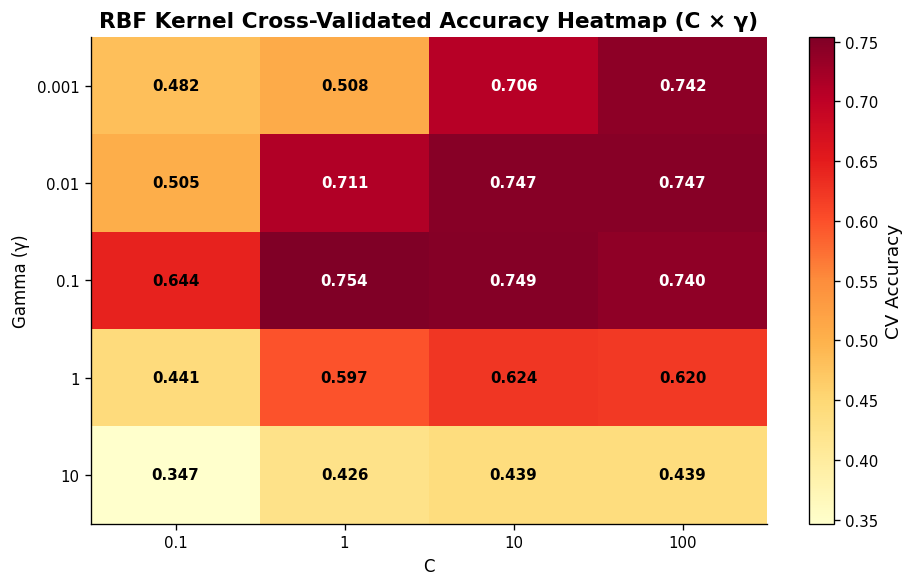

Best RBF config: C=1, γ=0.1, CV acc=0.7539


In [ ]:
# Figure 8: RBF Kernel, C × Gamma Heatmap
# The most important hyperparameter interaction for RBF

C_grid     = [0.1, 1, 10, 100]
gamma_grid = [0.001, 0.01, 0.1, 1, 10]

heatmap_acc = np.zeros((len(gamma_grid), len(C_grid)))

for i, gamma in enumerate(gamma_grid):
    for j, C in enumerate(C_grid):
        clf_hm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        scores = cross_val_score(clf_hm, X_train_std, y_train,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 scoring='accuracy', n_jobs=-1)
        heatmap_acc[i, j] = scores.mean()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_acc, cmap='YlOrRd', aspect='auto',
               vmin=heatmap_acc.min(), vmax=heatmap_acc.max())

ax.set_xticks(range(len(C_grid)));     ax.set_xticklabels([str(c) for c in C_grid])
ax.set_yticks(range(len(gamma_grid))); ax.set_yticklabels([str(g) for g in gamma_grid])
ax.set_xlabel('C', fontsize=10)
ax.set_ylabel('Gamma (γ)', fontsize=10)
ax.set_title('RBF Kernel Cross-Validated Accuracy Heatmap (C × γ)',
             fontweight='bold')

for i in range(len(gamma_grid)):
    for j in range(len(C_grid)):
        val = heatmap_acc[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, color='black' if val < 0.7 else 'white', fontweight='bold')

plt.colorbar(im, ax=ax, label='CV Accuracy')
plt.tight_layout()
plt.savefig('fig8_rbf_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

best_i, best_j = np.unravel_index(heatmap_acc.argmax(), heatmap_acc.shape)
print(f"Best RBF config: C={C_grid[best_j]}, γ={gamma_grid[best_i]}, "
      f"CV acc={heatmap_acc[best_i,best_j]:.4f}")


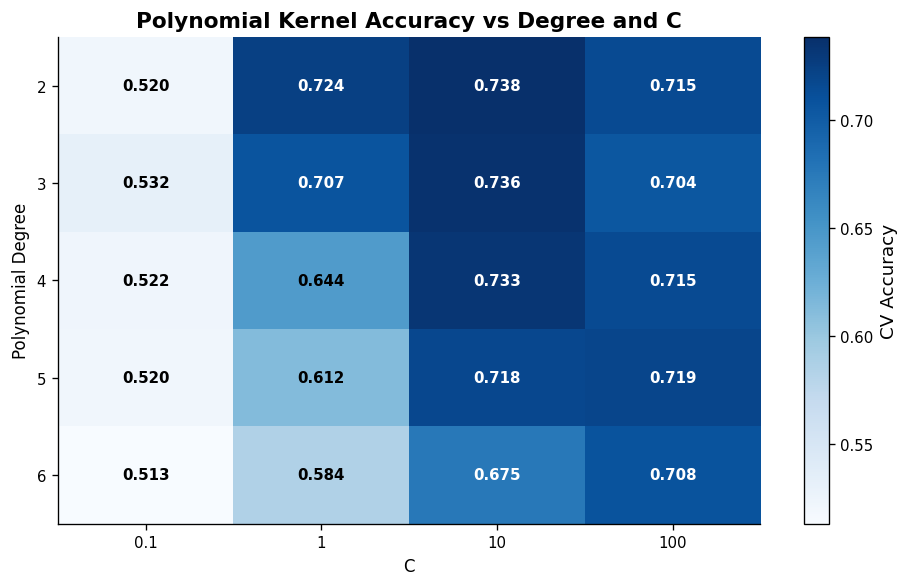

In [ ]:
# Figure 9: Polynomial Degree Sensitivity
# How does the polynomial degree change accuracy and boundary complexity?

degrees = [2, 3, 4, 5, 6]
poly_c_values = [0.1, 1, 10, 100]
poly_acc = np.zeros((len(degrees), len(poly_c_values)))

for i, deg in enumerate(degrees):
    for j, C in enumerate(poly_c_values):
        clf_p = SVC(kernel='poly', C=C, degree=deg, gamma='scale', random_state=42)
        scores = cross_val_score(clf_p, X_train_std, y_train,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 scoring='accuracy', n_jobs=-1)
        poly_acc[i, j] = scores.mean()

fig, ax = plt.subplots(figsize=(8, 5))
im2 = ax.imshow(poly_acc, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(poly_c_values))); ax.set_xticklabels([str(c) for c in poly_c_values])
ax.set_yticks(range(len(degrees)));       ax.set_yticklabels([str(d) for d in degrees])
ax.set_xlabel('C', fontsize=10)
ax.set_ylabel('Polynomial Degree', fontsize=10)
ax.set_title('Polynomial Kernel Accuracy vs Degree and C',
             fontweight='bold')

for i in range(len(degrees)):
    for j in range(len(poly_c_values)):
        ax.text(j, i, f'{poly_acc[i,j]:.3f}', ha='center', va='center',
                fontsize=9, color='white' if poly_acc[i,j]>0.65 else 'black',
                fontweight='bold')

plt.colorbar(im2, ax=ax, label='CV Accuracy')
plt.tight_layout()
plt.savefig('fig9_poly_degree_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 8. When Each Kernel Fails

Understanding failure modes is just as important as knowing when a kernel works. We now deliberately create conditions that break each kernel.


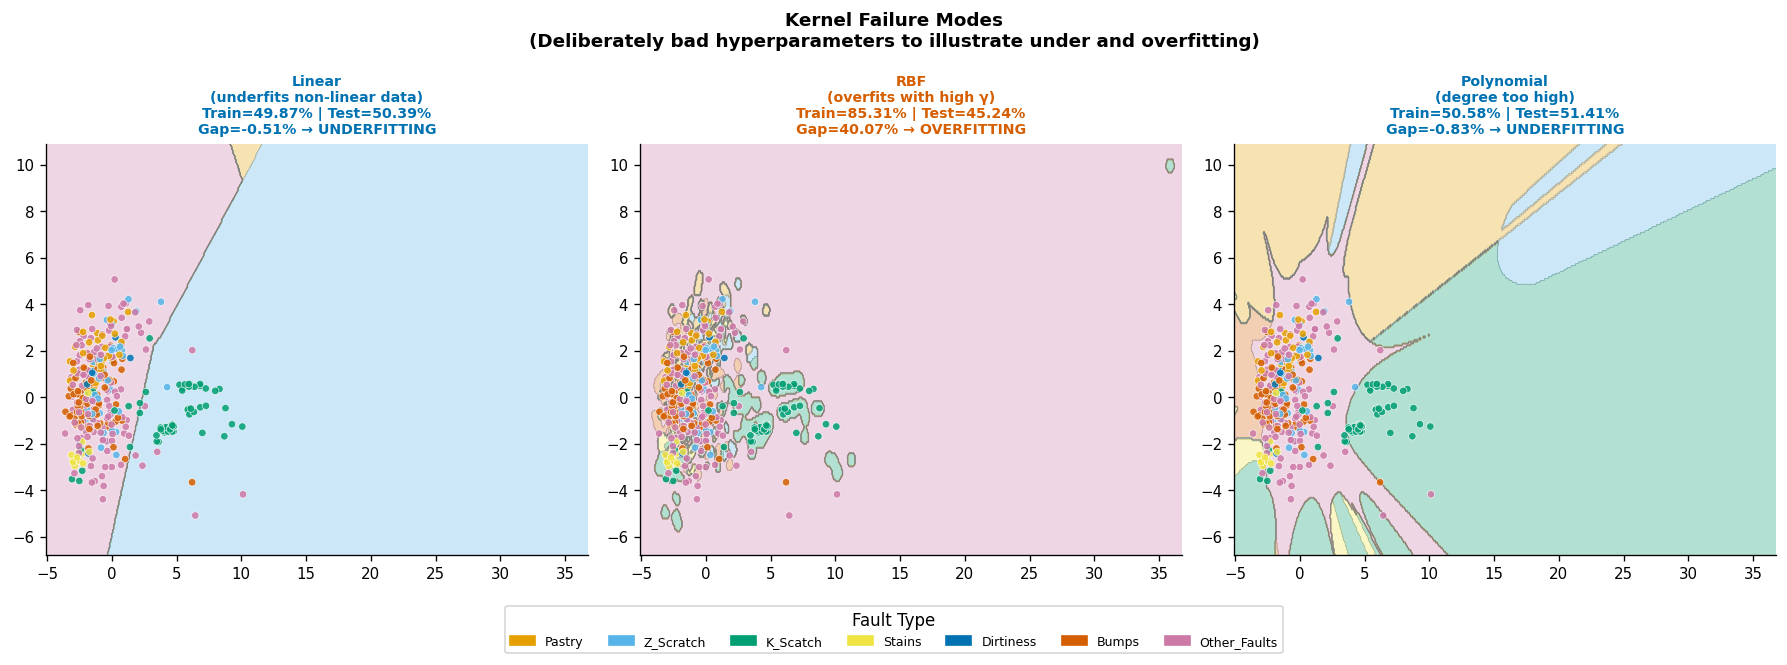

In [ ]:
# Figure 10: Failure Mode Demonstration
# We train each kernel at a configuration where it visibly fails,
# and compare train vs test accuracy to diagnose the problem.

failure_configs = {
    'Linear\n(underfits non-linear data)': SVC(kernel='linear', C=0.001),
    'RBF\n(overfits with high γ)':         SVC(kernel='rbf', C=100, gamma=10),
    'Polynomial\n(degree too high)':        SVC(kernel='poly', degree=7, C=100, gamma='scale'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, clf_fail) in zip(axes, failure_configs.items()):
    clf_fail.fit(X_train_2d, y_train)
    Z = clf_fail.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    train_acc = accuracy_score(y_train, clf_fail.predict(X_train_2d))
    test_acc  = accuracy_score(y_test,  clf_fail.predict(X_test_2d))
    gap = train_acc - test_acc

    ax.contourf(xx, yy, Z, alpha=0.30, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='grey', linewidths=0.5, alpha=0.4)
    ax.scatter(X_test_2d[:,0], X_test_2d[:,1],
               c=y_test, cmap=cmap_pts,
               edgecolors='white', linewidths=0.4, s=20, zorder=4, alpha=0.85)

    diagnosis = 'UNDERFITTING' if gap < 0.02 and test_acc < 0.65 else 'OVERFITTING'
    color_diag = '#0072B2' if diagnosis == 'UNDERFITTING' else '#D55E00'
    ax.set_title(f'{label}\nTrain={train_acc:.2%} | Test={test_acc:.2%}\n'
                 f'Gap={gap:.2%} → {diagnosis}',
                 fontweight='bold', fontsize=8.5, color=color_diag)

fig.legend(handles=patches, title='Fault Type', loc='lower center',
           ncol=7, fontsize=7.5, bbox_to_anchor=(0.5, -0.10))
plt.suptitle('Kernel Failure Modes\n'
             '(Deliberately bad hyperparameters to illustrate under and overfitting)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_failure_modes.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 9. Finding the Best Kernel with Grid Search

Now that we understand the parameter landscape, we use **GridSearchCV** with stratified 5-fold cross-validation to find the optimal kernel and hyperparameters simultaneously.


In [ ]:
# GridSearchCV: Search across kernels and hyperparameters
param_grid = [
    {'svc__kernel': ['linear'],
     'svc__C':      [0.1, 1, 10, 100]},
    {'svc__kernel': ['rbf'],
     'svc__C':      [0.1, 1, 10, 100],
     'svc__gamma':  [0.001, 0.01, 0.1, 1]},
    {'svc__kernel': ['poly'],
     'svc__C':      [0.1, 1, 10],
     'svc__degree': [2, 3, 4],
     'svc__gamma':  ['scale']},
]

pipe = Pipeline([
    ('scaler', StandardScaler()),   # ensures no data leakage
    ('svc', SVC(random_state=42))
])

grid_search = GridSearchCV(
    pipe, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=0
)

# Fit on raw (unscaled) training data Pipeline handles scaling internally
grid_search.fit(X_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"Test accuracy   : {grid_search.score(X_test, y_test):.4f}")


Best parameters : {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Best CV accuracy: 0.7532
Test accuracy   : 0.7763


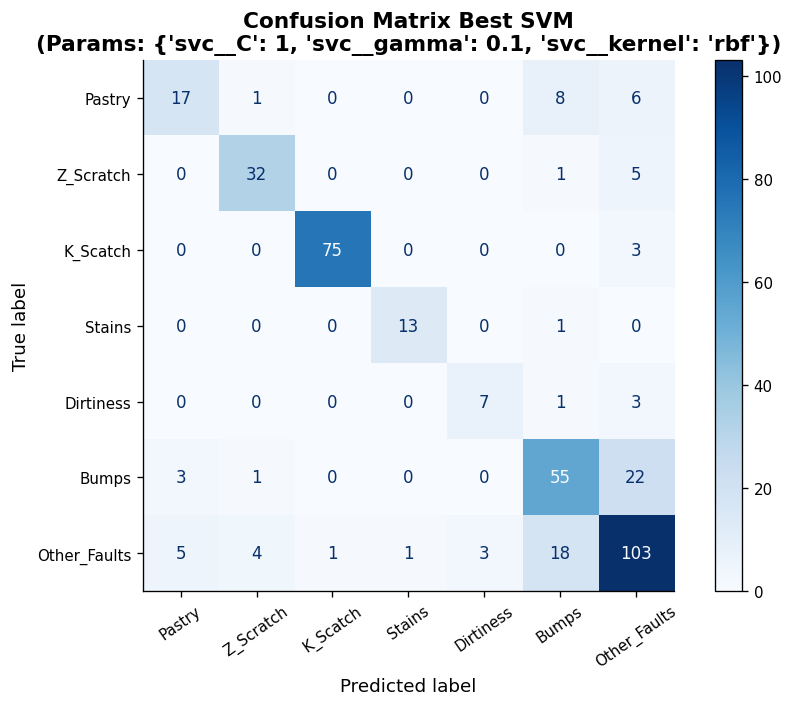


Full Classification Report:
              precision    recall  f1-score   support

      Pastry       0.68      0.53      0.60        32
   Z_Scratch       0.84      0.84      0.84        38
    K_Scatch       0.99      0.96      0.97        78
      Stains       0.93      0.93      0.93        14
   Dirtiness       0.70      0.64      0.67        11
       Bumps       0.65      0.68      0.67        81
Other_Faults       0.73      0.76      0.74       135

    accuracy                           0.78       389
   macro avg       0.79      0.76      0.77       389
weighted avg       0.78      0.78      0.78       389



In [ ]:
# Figure 11: Final Confusion Matrix, Best Model
y_pred_best = grid_search.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=35)
ax.set_title(f'Confusion Matrix Best SVM\n'
             f'(Params: {grid_search.best_params_})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES))


---
## 10. Summary Comparison Table


           Kernel  Test Acc  CV Mean
 Linear (default)  0.709512 0.733907
    RBF (default)  0.763496 0.740338
   Poly (default)  0.704370 0.706819
Best (GridSearch)  0.776350 0.753227


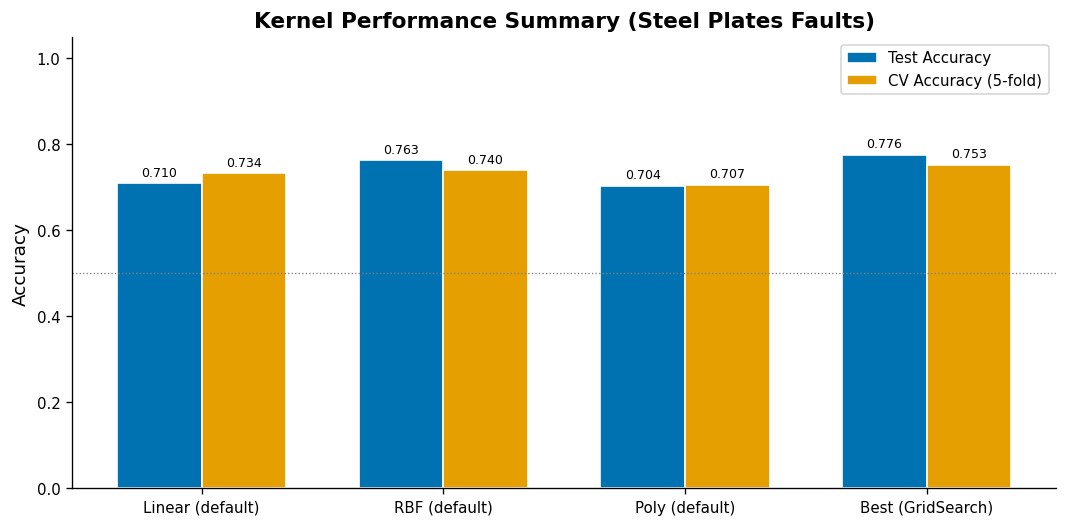

In [ ]:
# Figure 12: Final Comparison Bar Chart
summary_data = {
    'Kernel':   ['Linear (default)', 'RBF (default)', 'Poly (default)',
                 'Best (GridSearch)'],
    'Test Acc': [
        results_baseline['Linear']['test_acc'],
        results_baseline['RBF']['test_acc'],
        results_baseline['Polynomial']['test_acc'],
        grid_search.score(X_test, y_test)
    ],
    'CV Mean': [
        results_baseline['Linear']['cv_mean'],
        results_baseline['RBF']['cv_mean'],
        results_baseline['Polynomial']['cv_mean'],
        grid_search.best_score_
    ],
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(df_summary))
width = 0.35
b1 = ax.bar(x - width/2, df_summary['Test Acc'], width,
            label='Test Accuracy', color='#0072B2', edgecolor='white')
b2 = ax.bar(x + width/2, df_summary['CV Mean'], width,
            label='CV Accuracy (5-fold)', color='#E69F00', edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(df_summary['Kernel'], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Kernel Performance Summary (Steel Plates Faults)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=0.8)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('fig12_summary_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 11. Practical Kernel Selection Guide

Based on our experiments, here is a practical decision framework:

```
Your data
│
├── Many features (>100) or linearly separable?
│   └── → START with Linear kernel (fast, interpretable)
│
├── Complex, non-linear boundaries? Features interact?
│   ├── Clusters / radial structure?
│   │   └── → RBF kernel (most flexible, usually best default)
│   └── Known polynomial interactions in features?
│       └── → Polynomial kernel (degree 2–4)
│
└── Unsure?
    └── → GridSearchCV across all three with C and γ
```


### Limitations & Next Steps

- **Class imbalance:** Future work should apply SMOTE or class-weighted SVM (`class_weight='balanced'`) to improve performance on minority classes (Dirtiness, Stains).
- **Kernel not explored here:** Sigmoid kernel behaves similarly to a neural network's activation function and may be worth investigating.
- **Scalability:** SVM training scales as O(n²)–O(n³). For larger datasets, consider `LinearSVC` or `SGDClassifier` with kernel approximations (Nyström method).


---
## 12. References

1. **Buscema, M., Terzi, S., & Tastle, W.** (2010). Steel Plates Faults [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5J88N

2. **Cortes, C., & Vapnik, V.** (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297. https://doi.org/10.1007/BF00994018

3. **Schölkopf, B., & Smola, A. J.** (2002). *Learning with Kernels*. MIT Press.

4. **Scikit-learn developers** (2024). sklearn.svm.SVC — scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

5. **Hsu, C.-W., Chang, C.-C., & Lin, C.-J.** (2016). A Practical Guide to Support Vector Classification. https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf

6. **Müller, A. C., & Guido, S.** (2016). *Introduction to Machine Learning with Python*. O'Reilly Media. Chapter 2 (SVMs).

7. **Scikit-learn: Plot classification boundaries with different SVM Kernels.** https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html

> **GitHub Repository:** All code, figures, and the PDF tutorial are available at:  
> `https://github.com/usamaaidev18-dot/svm-kernel-tutorial`  
> Licensed under MIT License.
